# 01 — Data Cleaning & Initial EDA

Loads the raw Online Retail II workbook, applies the cleaning sequence, and profiles the
transaction data **without reference to the prediction target**.

Keeping this notebook target-free is deliberate: nothing here can be influenced by what
customers go on to spend after the cutoff, so any decision made from these charts is safe
by construction. Target-dependent analysis lives in notebook 02.

**Outputs:** `data/transactions_clean.csv`, figures 01–04 in `reports/figures/`.

In [1]:
import sys
from pathlib import Path

# Resolve the project root whether the notebook is run from notebooks/ or the repo root.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_prep import (
    CLEAN_TRANSACTIONS_PATH,
    FIGURES_DIR,
    NON_PRODUCT_CODES,
    clean_transactions,
    load_raw_transactions,
    summarize_stockcode_candidates,
)
from src.features import CUTOFF_DATE

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200, "display.max_columns", 40)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Write a figure to reports/figures/ at a consistent size and resolution."""
    fig.savefig(FIGURES_DIR / name, dpi=150, bbox_inches="tight")


print(f"project root : {PROJECT_ROOT}")
print(f"cutoff date  : {CUTOFF_DATE.date()}")

project root : C:\Users\monis\Desktop\CLV
cutoff date  : 2011-09-01


## 1. Load the raw data

Both Excel sheets are loaded and concatenated. The 2009–2010 sheet is not optional extra
data: it supplies the purchase history that makes tenure and cadence features meaningful
for customers who were already active well before the cutoff.

This step parses a 45 MB workbook and takes roughly 90 seconds.

In [2]:
raw = load_raw_transactions()
print(f"raw rows    : {len(raw):,}")
print(f"date range  : {raw['InvoiceDate'].min()} -> {raw['InvoiceDate'].max()}")
raw.head()

raw rows    : 1,067,371
date range  : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Missing value analysis (before cleaning)

Run before any cleaning so the picture reflects the data as delivered.

In [3]:
missing = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_pct": raw.isna().mean() * 100,
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


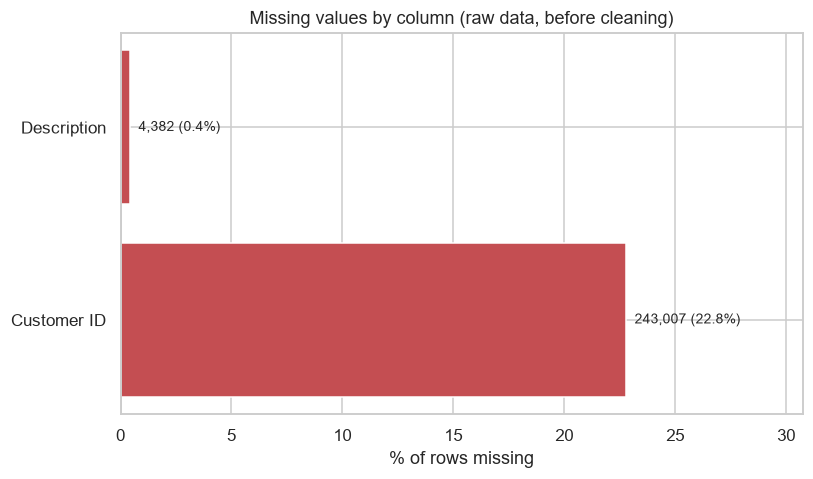

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = missing[missing["missing_count"] > 0]
ax.barh(plot_data.index, plot_data["missing_pct"], color=sns.color_palette("deep")[3])
for y, (count, pct) in enumerate(zip(plot_data["missing_count"], plot_data["missing_pct"])):
    ax.text(pct + 0.4, y, f"{count:,} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("% of rows missing")
ax.set_title("Missing values by column (raw data, before cleaning)")
ax.set_xlim(0, plot_data["missing_pct"].max() * 1.35)
save_fig(fig, "01_missing_values.png")
plt.show()

`Customer ID` is missing on about 23% of rows. Those rows cannot be attributed to a
customer and therefore cannot contribute to a customer-level target, so they are dropped
rather than imputed — inventing a customer identity would fabricate the very entity we
are modelling. Missing `Description` is cosmetic and does not affect any feature.

## 3. Identifying non-product stock codes

Rather than trusting a hardcoded list, every stock code that fails the product-code
pattern (a 5-digit number with an optional letter suffix) is surfaced with its
descriptions and revenue, and judged individually.

In [5]:
candidates = summarize_stockcode_candidates(raw)
print(f"{len(candidates)} candidate codes across {candidates['n_rows'].sum():,} rows")
candidates

61 candidate codes across 6,093 rows


,n_rows,n_customers,revenue,descriptions,removed
stock_code,,,,,
DOT,1446,1,322647.470,DOTCOM POSTAGE,True
POST,2122,496,112341.000,POSTAGE,True
C2,282,45,13386.000,CARRIAGE,True
ADJUST,67,53,6835.240,Adjustment by Peter on 24/05/2010 1 | Adjustme...,True
ADJUST2,3,3,731.050,Adjustment by Peter on Jun 25 2010,True
...,...,...,...,...,...
D,177,55,-13484.540,Discount,True
BANK CHARGES,102,22,-35562.629,Bank Charges | Bank Charges,True
M,1426,582,-82781.270,Manual,True


Two judgements worth recording:

- **Kept as products:** `SP1002` ("KID'S CHALKBOARD/EASEL") and `PADS` ("PADS TO MATCH ALL
  CUSHIONS") have non-standard codes but are genuine merchandise, so removing them would
  discard real sales.
- **Already gone by step 1:** the `DCGS*` and `gift_0001_*` codes carry no `Customer ID`
  and are removed by the missing-customer filter before the stock-code step is reached.
  This is visible in the cleaning log below — step 5 drops only ~2.8k rows, far fewer than
  the candidate inventory above.

The codes actually removed are postage, carriage, manual adjustments, bank charges,
discounts and test entries — fees and corrections rather than merchandise.

In [6]:
print("Removed as non-product:")
for c in sorted(NON_PRODUCT_CODES):
    print(f"  {c}")

Removed as non-product:
  ADJUST
  ADJUST2
  BANK CHARGES
  C2
  D
  DOT
  M
  POST
  TEST001
  TEST002


## 4. Cleaning

Steps are applied in a fixed order, and the row count is logged after each one so the cost
of every rule is explicit. Order matters: dropping rows without a customer first changes
what all later steps see.

In [7]:
transactions, cleaning_log = clean_transactions(raw)
cleaning_log

,step,rows,customers,rows_dropped
0,0. raw (both sheets),1067371,5942,0
1,1. drop missing Customer ID,824364,5942,243007
2,2. drop exact duplicates,797885,5942,26479
3,3. drop cancellations and Quantity <= 0,779495,5881,18390
4,4. drop Price <= 0,779425,5878,70
5,5. drop non-product stock codes,776596,5852,2829
6,6. keep high-value outliers (no rows dropped),776596,5852,0
7,7. type fixes and line_revenue,776596,5852,0


In [8]:
retained = len(transactions) / len(raw)
print(f"retained {len(transactions):,} of {len(raw):,} rows ({retained:.1%})")
print(f"customers : {transactions['Customer ID'].nunique():,}")
print(f"invoices  : {transactions['Invoice'].nunique():,}")

retained 776,596 of 1,067,371 rows (72.8%)
customers : 5,852
invoices  : 36,594


## 5. Transaction statistics

In [9]:
stats = pd.Series({
    "rows": f"{len(transactions):,}",
    "customers": f"{transactions['Customer ID'].nunique():,}",
    "invoices": f"{transactions['Invoice'].nunique():,}",
    "products": f"{transactions['StockCode'].nunique():,}",
    "countries": f"{transactions['Country'].nunique():,}",
    "first transaction": str(transactions["InvoiceDate"].min()),
    "last transaction": str(transactions["InvoiceDate"].max()),
    "total revenue": f"{transactions['line_revenue'].sum():,.2f}",
    "median line revenue": f"{transactions['line_revenue'].median():,.2f}",
    "mean revenue / customer": f"{transactions.groupby('Customer ID')['line_revenue'].sum().mean():,.2f}",
    "median revenue / customer": f"{transactions.groupby('Customer ID')['line_revenue'].sum().median():,.2f}",
}).to_frame("value")
stats

,value
rows,"776,596"
customers,"5,852"
invoices,"36,594"
products,"4,621"
countries,41
first transaction,2009-12-01 07:45:00
last transaction,2011-12-09 12:50:00
total revenue,"17,068,582.74"
median line revenue,12.45
mean revenue / customer,"2,916.71"


Mean revenue per customer sits far above the median — the first sign that the customer
value distribution is heavily right-skewed, which drives both the log target transform and
the choice of MAE over RMSE as the headline metric.

## 6. Revenue concentration (Pareto curve)

How much of total revenue comes from the top customers. This is the commercial premise of
a CLV model: if value were spread evenly, ranking customers would not be worth doing.

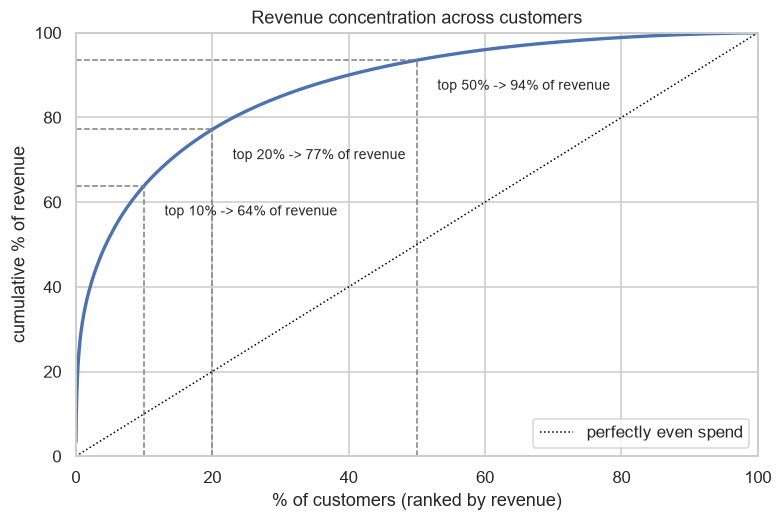

top 10% of customers: 63.9% of revenue
top 20% of customers: 77.2% of revenue
top 50% of customers: 93.5% of revenue


In [10]:
customer_revenue = (
    transactions.groupby("Customer ID")["line_revenue"].sum().sort_values(ascending=False)
)
cum_revenue_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = np.arange(1, len(customer_revenue) + 1) / len(customer_revenue) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(customer_pct, cum_revenue_pct, linewidth=2.2)
for share in (10, 20, 50):
    captured = np.interp(share, customer_pct, cum_revenue_pct)
    ax.plot([share, share], [0, captured], "--", color="grey", linewidth=1)
    ax.plot([0, share], [captured, captured], "--", color="grey", linewidth=1)
    ax.annotate(f"top {share}% -> {captured:.0f}% of revenue",
                xy=(share, captured), xytext=(share + 3, captured - 7), fontsize=9)
ax.plot([0, 100], [0, 100], ":", color="black", linewidth=1, label="perfectly even spend")
ax.set_xlabel("% of customers (ranked by revenue)")
ax.set_ylabel("cumulative % of revenue")
ax.set_title("Revenue concentration across customers")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc="lower right")
save_fig(fig, "02_revenue_pareto.png")
plt.show()

for share in (10, 20, 50):
    print(f"top {share:>2}% of customers: {np.interp(share, customer_pct, cum_revenue_pct):.1f}% of revenue")

## 7. Purchase frequency distribution

Distinct invoices per customer. The shape here determines how much history the model has
to work with for a typical customer.

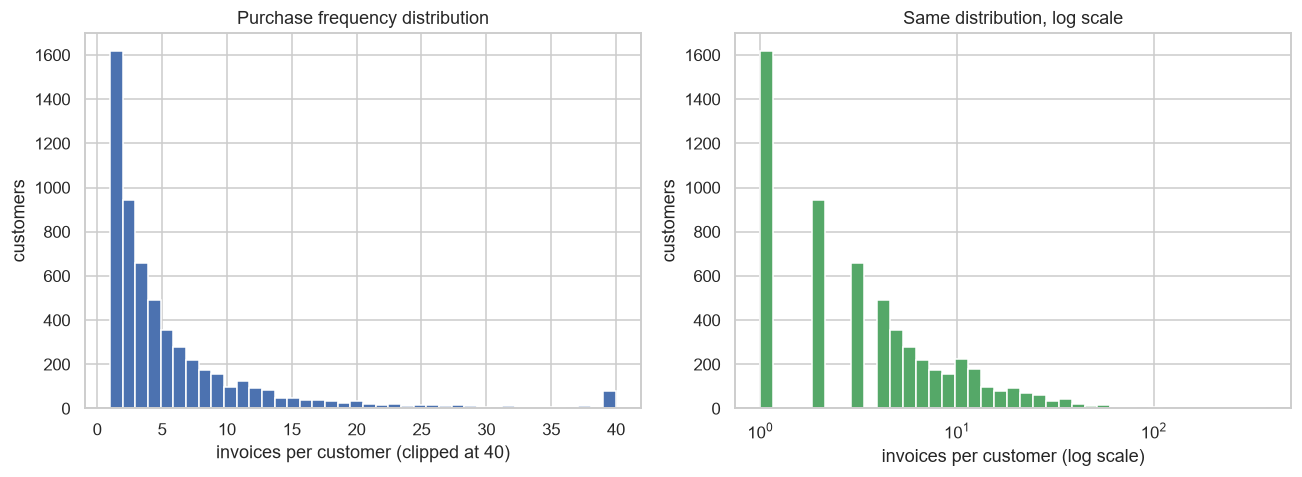

count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000

single-purchase customers: 1,618 (27.6%)


In [11]:
frequency = transactions.groupby("Customer ID")["Invoice"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(frequency.clip(upper=40), bins=40, color=sns.color_palette("deep")[0])
axes[0].set_xlabel("invoices per customer (clipped at 40)")
axes[0].set_ylabel("customers")
axes[0].set_title("Purchase frequency distribution")

axes[1].hist(frequency, bins=np.logspace(0, np.log10(frequency.max()), 40),
             color=sns.color_palette("deep")[2])
axes[1].set_xscale("log")
axes[1].set_xlabel("invoices per customer (log scale)")
axes[1].set_ylabel("customers")
axes[1].set_title("Same distribution, log scale")
fig.tight_layout()
save_fig(fig, "03_purchase_frequency.png")
plt.show()

print(frequency.describe().to_string())
print(f"\nsingle-purchase customers: {(frequency == 1).sum():,} ({(frequency == 1).mean():.1%})")

## 8. Monthly revenue over time

The cutoff is marked, along with the 90-day prediction window. This confirms the split
lands in a normal trading period and that the prediction window is fully covered by the
data rather than running off the end of it.

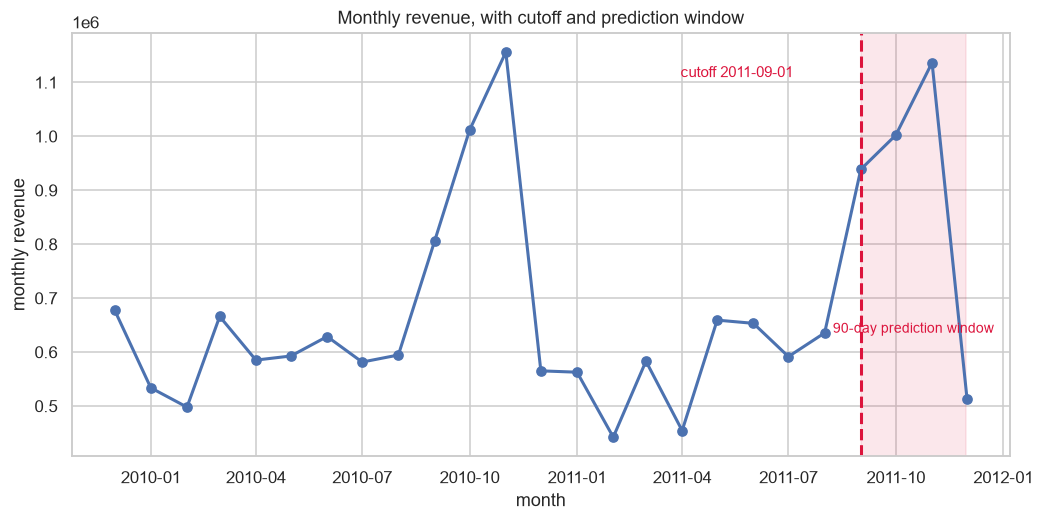

observation window : 2009-12-01 -> 2011-09-01
prediction window  : 2011-09-01 -> 2011-11-30
last transaction   : 2011-12-09


In [12]:
monthly = (
    transactions.set_index("InvoiceDate")["line_revenue"]
    .resample("MS").sum()
)
prediction_end = CUTOFF_DATE + pd.Timedelta(days=90)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2)
ax.axvline(CUTOFF_DATE, color="crimson", linestyle="--", linewidth=2)
ax.axvspan(CUTOFF_DATE, prediction_end, color="crimson", alpha=0.10)
ax.annotate(f"cutoff {CUTOFF_DATE.date()}", xy=(CUTOFF_DATE, monthly.max() * 0.96),
            xytext=(-118, 0), textcoords="offset points", color="crimson", fontsize=10)
ax.annotate("90-day prediction window", xy=(CUTOFF_DATE + pd.Timedelta(days=45), monthly.max() * 0.55),
            ha="center", color="crimson", fontsize=9)
ax.set_ylabel("monthly revenue")
ax.set_xlabel("month")
ax.set_title("Monthly revenue, with cutoff and prediction window")
save_fig(fig, "04_monthly_revenue.png")
plt.show()

print(f"observation window : {monthly.index.min().date()} -> {CUTOFF_DATE.date()}")
print(f"prediction window  : {CUTOFF_DATE.date()} -> {prediction_end.date()}")
print(f"last transaction   : {transactions['InvoiceDate'].max().date()}")

The final months show the retailer's seasonal Q4 peak. The prediction window (Sep–Nov 2011)
sits inside that ramp-up, so predicted values reflect pre-Christmas trading — worth
remembering when reading absolute monetary figures later.

Note the December 2011 drop-off is an artefact: the data ends on 2011-12-09, so that month
is only partially observed. It falls outside both windows and does not affect the model.

## 9. Save the cleaned transactions

Written to `data/transactions_clean.csv` so notebooks 02 and 03 can skip the slow Excel parse.

In [13]:
transactions.to_csv(CLEAN_TRANSACTIONS_PATH, index=False)
print(f"saved {len(transactions):,} rows -> {CLEAN_TRANSACTIONS_PATH}")

saved 776,596 rows -> C:\Users\monis\Desktop\CLV\data\transactions_clean.csv
